# Streaming / online trackers

These estimators ingest one sample at a time with bounded per-update cost
(`partial_fit(t, y)`), for control loops and big-data streams. Each filter is
the streaming twin of a batch method and carries built-in **drift detection**.

- `EACFilter` - streaming equal-areas (twin of `fit_eac`).
- `LSIFilter` - streaming Legendre spectrum (twin of `fit_lsi`); same API plus
  an `order=` knob.
- `FilterBank` - many independent streams updated in lockstep.
- `FusedChiSquareDetector` - pools a bank's innovations into one fault test.

In [1]:
%matplotlib inline
import warnings
import numpy as np
import matplotlib.pyplot as plt

# Fitting at extreme parameter trials can overflow exp() harmlessly; keep the
# guide output clean.
warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
rng = np.random.default_rng(0)

## `EACFilter` - track a drifting parameter

The exponential rate `b` jumps mid-stream; the filter re-adapts (its drift test
detects the change and re-arms the covariance).

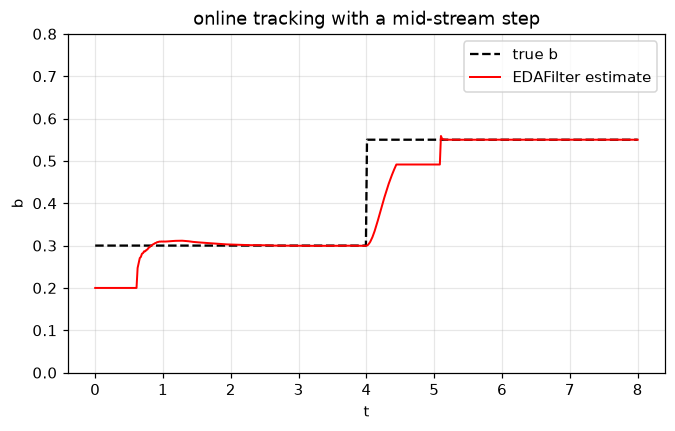

In [2]:
from dtfit import EACFilter

T = 500
t = np.linspace(0, 8, T)
b_true = np.where(t < 4, 0.30, 0.55)
y = np.exp(b_true * t) + rng.normal(0, 0.05, T)

flt = EACFilter("exp(b*t)", "t", p0=[0.2], window_size=40, q_diag=[1e-4], r=0.5)
track = []
for ti, yi in zip(t, y):
    flt.partial_fit(ti, yi)
    track.append(flt.p[0])

plt.plot(t, b_true, "k--", label="true b")
plt.plot(t, track, "r-", lw=1.3, label="EACFilter estimate")
plt.ylim(0, 0.8); plt.legend(); plt.title("online tracking with a mid-stream step")
plt.xlabel("t"); plt.ylabel("b"); plt.show()

## `FilterBank` - many streams at once

Build `K` identically-configured filters for one model and drive them over a
block of samples. `run` returns final per-stream parameters and drift counts.

In [3]:
from dtfit import FilterBank

K = 4
t = np.linspace(0, 20, 400)
b_true = np.array([0.30, 0.50, 0.70, 0.90])
Y = np.column_stack([np.exp(b * t) + rng.normal(0, 0.05, t.size) for b in b_true])

bank = FilterBank.from_model("a*exp(b*t)", "t", K,
                             p0=[1.0, 0.4], window_size=40,
                             q_diag=[1e-4, 1e-3], r=0.3)
out = bank.run(t, Y, n_jobs=1)        # n_jobs>1 fans streams across threads
print("recovered b:", np.round(out["params"][:, 1], 3))
print("true b     :", b_true)
print("drift counts:", out["n_drifts"])

recovered b: [0.3   0.5   0.695 0.882]
true b     : [0.3 0.5 0.7 0.9]
drift counts: [0 0 2 2]


## `FusedChiSquareDetector` - catch a shared fault

A change that hits **every** stream (here an amplitude collapse at t = 20) is
weak in any single innovation but strong in the pooled `chi2(K)` statistic. The
detector ingests samples into the bank and flags the step where it fires.

flags raised : 1
first flag at : t = 20.0 (fault at t=20)


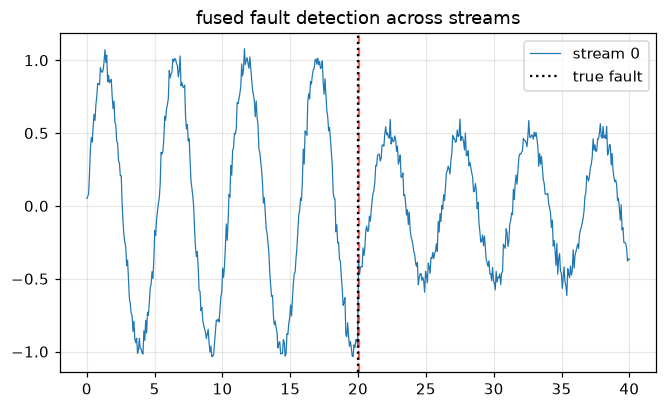

In [4]:
from dtfit import FilterBank

K = 3
t = np.linspace(0, 40, 600)
amp = np.where(t < 20, 1.0, 0.5)                    # shared fault at t = 20
phases = (0.0, 0.7, 1.4)
Y = np.column_stack([amp * np.sin(1.2 * t + p) + rng.normal(0, 0.05, t.size)
                     for p in phases])

bank = FilterBank.from_model("A*sin(1.2*t + p)", "t", K,
                             p0=[1.0, 0.0], window_size=40)
det = bank.fused_detector(alpha=1e-4)
fired = [t[s] for s in range(t.size) if det.update(t[s], Y[s])]

print("flags raised :", det.n_flags_)
print("first flag at : t =", round(fired[0], 1) if fired else None, "(fault at t=20)")

plt.plot(t, Y[:, 0], lw=0.8, label="stream 0")
for f in fired:
    plt.axvline(f, color="r", ls="--", alpha=0.6)
plt.axvline(20, color="k", ls=":", label="true fault")
plt.legend(); plt.title("fused fault detection across streams"); plt.show()